# Lab 3: Raster Analysis — Terrain, Hazards, and Catchments
## ENCN205 — Applied Data Analysis for Civil and Natural Systems
### University of Canterbury | Te Whare Wānanga o Waitaha

**Duration:** 2–3 hours
**Week:** 3
**Prerequisites:** Labs 1–2 completed (data loading, CRS, vector analysis)

---

### Learning Objectives
By the end of this lab you will be able to:
1. Load and inspect real raster data (DEMs) using numpy
2. Visualise elevation data with matplotlib colour maps and hillshade
3. Perform map algebra: reclassification, masking, arithmetic operations
4. Compute terrain derivatives: slope and aspect
5. Crop and mask raster data using vector boundaries
6. Extract raster values at point locations
7. Compute zonal statistics (mean elevation per zone)
8. Combine raster and vector data for hazard assessment

### Engineering Scenario
> **You are analysing terrain** on Banks Peninsula for a slope stability and
> seismic hazard assessment. Using a real 8m Digital Elevation Model from LINZ,
> you will compute terrain derivatives, identify steep volcanic slopes, and
> extract ground shaking intensities at building locations to support
> infrastructure planning decisions.
>
> Banks Peninsula is a volcanic landscape with two main eroded stratovolcanoes
> (Lyttelton and Akaroa), steep radial erosion valleys, and peaks up to 780m.
> This terrain makes it an excellent case study for raster analysis.

## 1. Setup and Raster Fundamentals

### What is a Raster?
A **raster** is a grid of cells (pixels), each holding a numeric value.
In engineering GIS:

| Raster Type | Values Represent | Example |
|-------------|-----------------|--------|
| DEM | Elevation (metres) | Terrain analysis, flood modelling |
| Slope grid | Degrees or percent | Stability assessment |
| Land cover | Category codes | Runoff estimation |
| Hazard intensity | Shaking (MMI, PGA) | Seismic risk assessment |

### The Python Raster Stack
| Library | Purpose |
|---------|--------|
| `numpy` | Array operations and math |
| `xarray` | Labelled multi-dimensional arrays |
| `rioxarray` | Geospatial raster I/O (read GeoTIFF, manage CRS) |
| `matplotlib` | Visualisation |
| `rasterstats` | Zonal statistics (raster + vector) |

**In this lab** we use a real 8m DEM from LINZ (NZ 8m Digital Elevation Model 2012)
covering part of Banks Peninsula. The DEM has been pre-exported as a numpy array.

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point, box, Polygon
import warnings
warnings.filterwarnings('ignore')

print("Core libraries loaded!")
print("\nThis lab uses a real 8m DEM from LINZ covering Banks Peninsula.")
print("In real projects you would load GeoTIFF files with rioxarray.")

Core libraries loaded!

This lab uses a real 8m DEM from LINZ covering Banks Peninsula.
In real projects you would load GeoTIFF files with rioxarray.


## 2. Loading and Inspecting the DEM

We'll load a **real** DEM from the LINZ NZ 8m Digital Elevation Model 2012.
This covers part of Banks Peninsula — a volcanic landscape with:
- An eroded stratovolcano centre (peaks up to 780m)
- Steep radial erosion valleys cut by streams
- Low-elevation coastal plains and harbour basins
- A connecting saddle ridge between the two peaks

The DEM is stored as a numpy `.npy` file with accompanying metadata in JSON.

In [3]:
# ── Load the real Banks Peninsula DEM ──
dem = np.load('data/banks_peninsula_dem.npy')

with open('data/banks_peninsula_meta.json') as f:
    meta = json.load(f)

nrows, ncols = meta['rows'], meta['cols']
resolution = meta['resolution_m']
x_origin = meta['x_origin']
y_origin = meta['y_origin']

# Build coordinate arrays (NZTM2000)
x_coords = np.arange(x_origin, x_origin + ncols * resolution, resolution)
y_coords = np.arange(y_origin, y_origin + nrows * resolution, resolution)
X, Y = np.meshgrid(x_coords, y_coords)

print(f"DEM Shape: {dem.shape} (rows x columns)")
print(f"Resolution: {resolution}m")
print(f"CRS: {meta['crs']} ({meta['crs_name']})")
print(f"Extent: {x_origin:,} to {meta['x_max']:,} E")
print(f"         {y_origin:,} to {meta['y_max']:,} N")
print(f"Coverage: {ncols * resolution / 1000:.0f} km x {nrows * resolution / 1000:.0f} km")
print(f"Elevation range: {dem[dem>0].min():.1f}m to {dem.max():.1f}m")
print(f"Mean elevation: {dem[dem>0].mean():.1f}m")
print(f"Data type: {dem.dtype}")
print(f"Source: {meta['source']}")

DEM Shape: (500, 500) (rows x columns)
Resolution: 8m
CRS: EPSG:2193 (NZTM2000)
Extent: 1,575,268 to 1,579,268 E
         5,167,740 to 5,171,740 N
Coverage: 4 km x 4 km
Elevation range: 1.2m to 780.5m
Mean elevation: 264.0m
Data type: float32
Source: LINZ NZ 8m Digital Elevation Model 2012


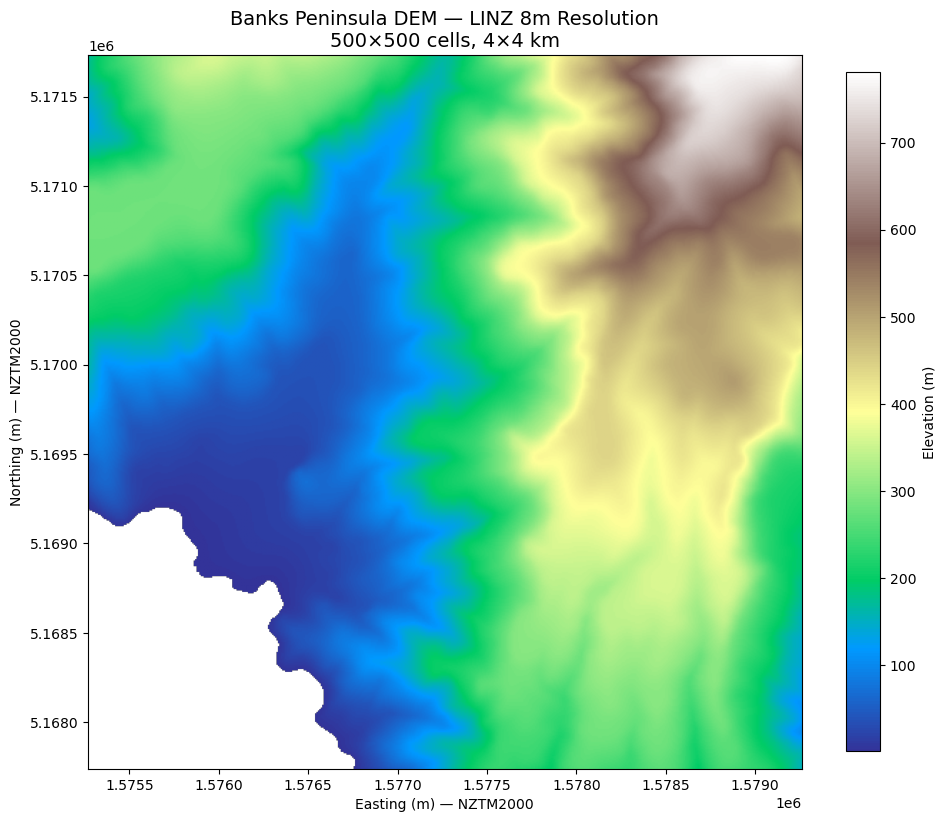

In [4]:
# Visualise the DEM
extent = [x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]]

# Mask zero-elevation cells for cleaner display
dem_display = np.where(dem > 0, dem, np.nan)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(dem_display, extent=extent, origin='lower', cmap='terrain', aspect='equal')
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.7)
ax.set_title('Banks Peninsula DEM — LINZ 8m Resolution\n'
             f'{ncols}×{nrows} cells, {ncols*resolution/1000:.0f}×{nrows*resolution/1000:.0f} km',
             fontsize=14)
ax.set_xlabel('Easting (m) — NZTM2000')
ax.set_ylabel('Northing (m) — NZTM2000')
plt.tight_layout()
plt.show()

## 3. Hillshade: Simulating Terrain Illumination

A **hillshade** creates a shaded relief effect by simulating sunlight on the terrain.
It improves the visual interpretation of elevation data.

The calculation considers:
- **Azimuth**: Direction of the sun (315° = northwest is standard)
- **Altitude**: Sun angle above horizon (45° is typical)

Hillshade is a **focal** raster operation — each cell's value depends on its
neighbours (using a 3×3 gradient kernel).

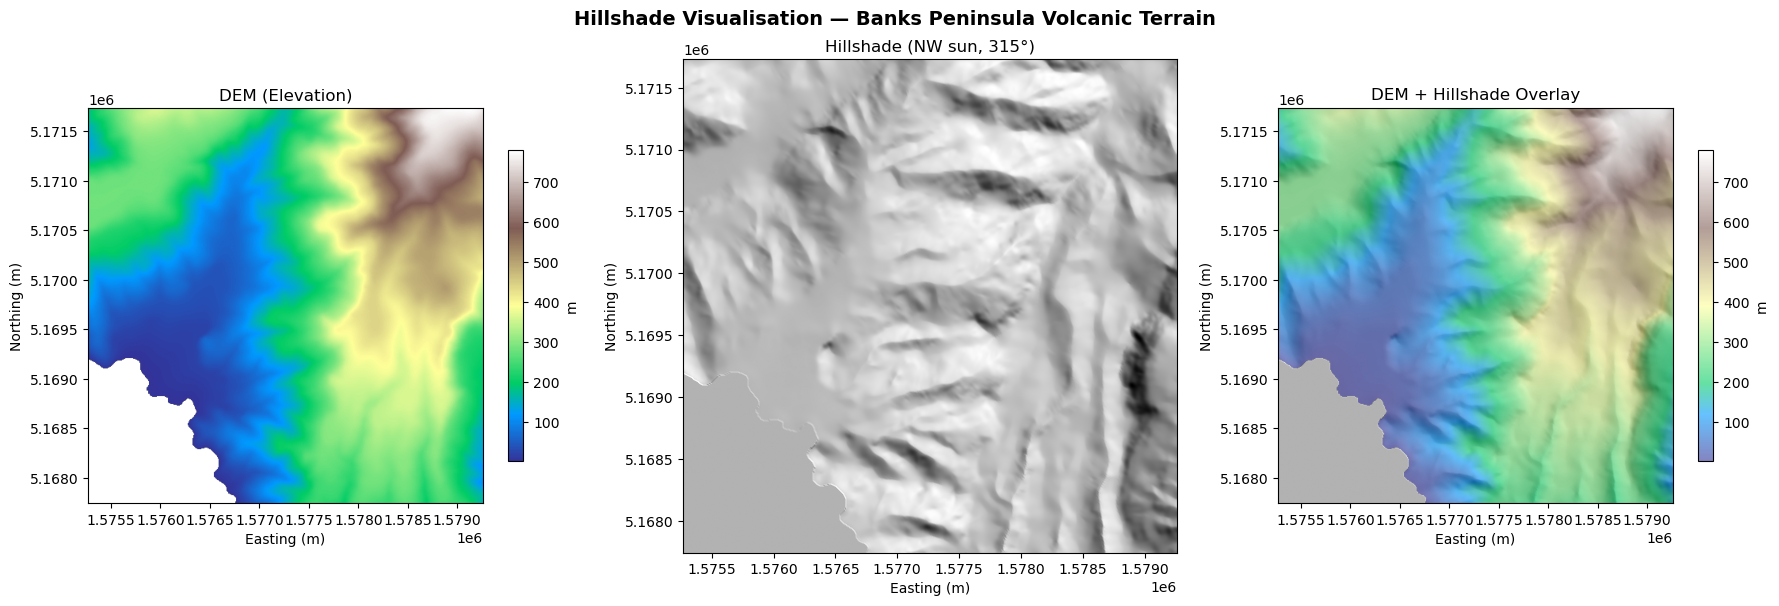

In [5]:
def compute_hillshade(dem, azimuth=315, altitude=45, resolution=8):
    """Compute hillshade from a DEM array."""
    az_rad = np.radians(azimuth)
    alt_rad = np.radians(altitude)
    dy, dx = np.gradient(dem, resolution)
    slope = np.arctan(np.sqrt(dx**2 + dy**2))
    aspect = np.arctan2(-dx, dy)
    hillshade = (np.sin(alt_rad) * np.cos(slope) +
                 np.cos(alt_rad) * np.sin(slope) * np.cos(az_rad - aspect))
    return np.clip(hillshade, 0, 1)

hs = compute_hillshade(dem, resolution=resolution)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plain DEM
im1 = axes[0].imshow(dem_display, extent=extent, origin='lower', cmap='terrain')
axes[0].set_title('DEM (Elevation)', fontsize=12)
plt.colorbar(im1, ax=axes[0], shrink=0.6, label='m')

# Hillshade alone
axes[1].imshow(hs, extent=extent, origin='lower', cmap='gray')
axes[1].set_title('Hillshade (NW sun, 315°)', fontsize=12)

# DEM + Hillshade combined
axes[2].imshow(hs, extent=extent, origin='lower', cmap='gray', alpha=1)
im3 = axes[2].imshow(dem_display, extent=extent, origin='lower', cmap='terrain', alpha=0.6)
axes[2].set_title('DEM + Hillshade Overlay', fontsize=12)
plt.colorbar(im3, ax=axes[2], shrink=0.6, label='m')

for ax in axes:
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

plt.suptitle('Hillshade Visualisation — Banks Peninsula Volcanic Terrain',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

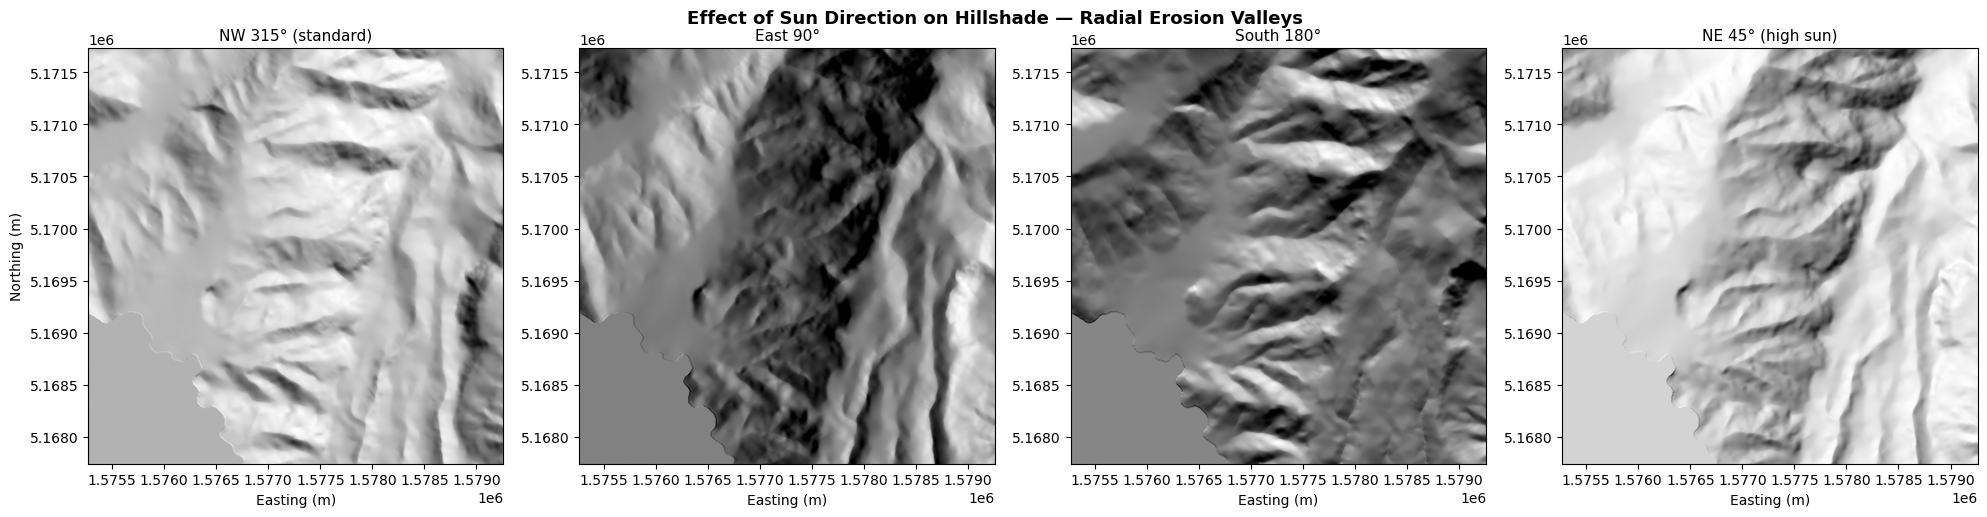

Notice how different sun angles reveal different valley orientations.
Valleys aligned PARALLEL to the light source become invisible.


In [6]:
# ── Compare different sun directions ──
sun_configs = [
    ('NW 315° (standard)', 315, 45),
    ('East 90°', 90, 30),
    ('South 180°', 180, 30),
    ('NE 45° (high sun)', 45, 60)
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, az, alt) in zip(axes, sun_configs):
    h = compute_hillshade(dem, azimuth=az, altitude=alt, resolution=resolution)
    ax.imshow(h, extent=extent, origin='lower', cmap='gray')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Easting (m)')

axes[0].set_ylabel('Northing (m)')
plt.suptitle('Effect of Sun Direction on Hillshade — Radial Erosion Valleys',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice how different sun angles reveal different valley orientations.')
print('Valleys aligned PARALLEL to the light source become invisible.')

## 4. Map Algebra: Reclassification and Masking

**Map algebra** applies mathematical operations to raster grids.
There are four types:

| Type | Operation | Example |
|------|-----------|--------|
| **Local** | Cell-by-cell | Reclassify elevation, mask by threshold |
| **Focal** | Neighbourhood window | Slope, smoothing, hillshade |
| **Zonal** | Summarise within zones | Mean elevation per catchment |
| **Global** | Entire raster | Min, max, histogram |

### Reclassification
Convert continuous elevation into discrete engineering classes.
For Banks Peninsula's volcanic terrain, useful classes are:

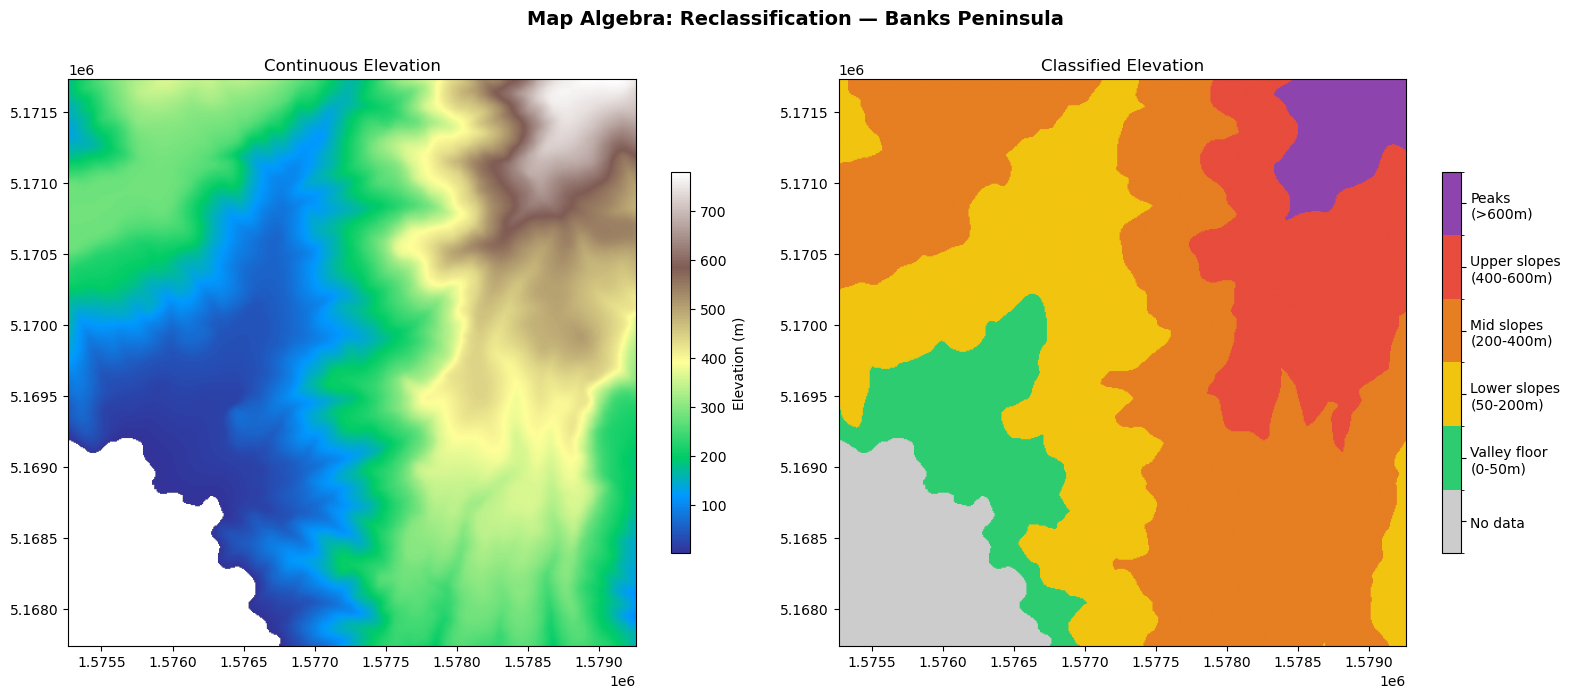

  Class 1 — Valley floor (0-50m): 24,135 cells, 1.54 km²
  Class 2 — Lower slopes (50-200m): 64,016 cells, 4.10 km²
  Class 3 — Mid slopes (200-400m): 91,109 cells, 5.83 km²
  Class 4 — Upper slopes (400-600m): 37,310 cells, 2.39 km²
  Class 5 — Peaks (>600m): 10,257 cells, 0.66 km²


In [7]:
# ── Reclassification: elevation into engineering-relevant classes ──
classes = np.zeros_like(dem, dtype=np.int32)
classes[dem == 0] = 0                          # No data
classes[(dem > 0) & (dem <= 50)] = 1            # Valley floors / coastal
classes[(dem > 50) & (dem <= 200)] = 2          # Lower slopes
classes[(dem > 200) & (dem <= 400)] = 3         # Mid slopes
classes[(dem > 400) & (dem <= 600)] = 4         # Upper slopes
classes[dem > 600] = 5                          # Volcanic peaks

# Custom colourmap
cmap_classes = mcolors.ListedColormap(['#cccccc', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = mcolors.BoundaryNorm(bounds, cmap_classes.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Continuous
im1 = axes[0].imshow(dem_display, extent=extent, origin='lower', cmap='terrain')
axes[0].set_title('Continuous Elevation', fontsize=12)
plt.colorbar(im1, ax=axes[0], shrink=0.6, label='Elevation (m)')

# Classified
im2 = axes[1].imshow(classes, extent=extent, origin='lower', cmap=cmap_classes, norm=norm)
cbar = plt.colorbar(im2, ax=axes[1], shrink=0.6, ticks=[0,1,2,3,4,5])
cbar.set_ticklabels(['No data', 'Valley floor\n(0-50m)', 'Lower slopes\n(50-200m)',
                      'Mid slopes\n(200-400m)', 'Upper slopes\n(400-600m)', 'Peaks\n(>600m)'])
axes[1].set_title('Classified Elevation', fontsize=12)

plt.suptitle('Map Algebra: Reclassification — Banks Peninsula',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistics per class
cell_area = resolution ** 2
for c, label in [(1, 'Valley floor (0-50m)'), (2, 'Lower slopes (50-200m)'),
                  (3, 'Mid slopes (200-400m)'), (4, 'Upper slopes (400-600m)'),
                  (5, 'Peaks (>600m)')]:
    count = np.sum(classes == c)
    area_km2 = count * cell_area / 1e6
    print(f'  Class {c} — {label}: {count:,} cells, {area_km2:.2f} km²')

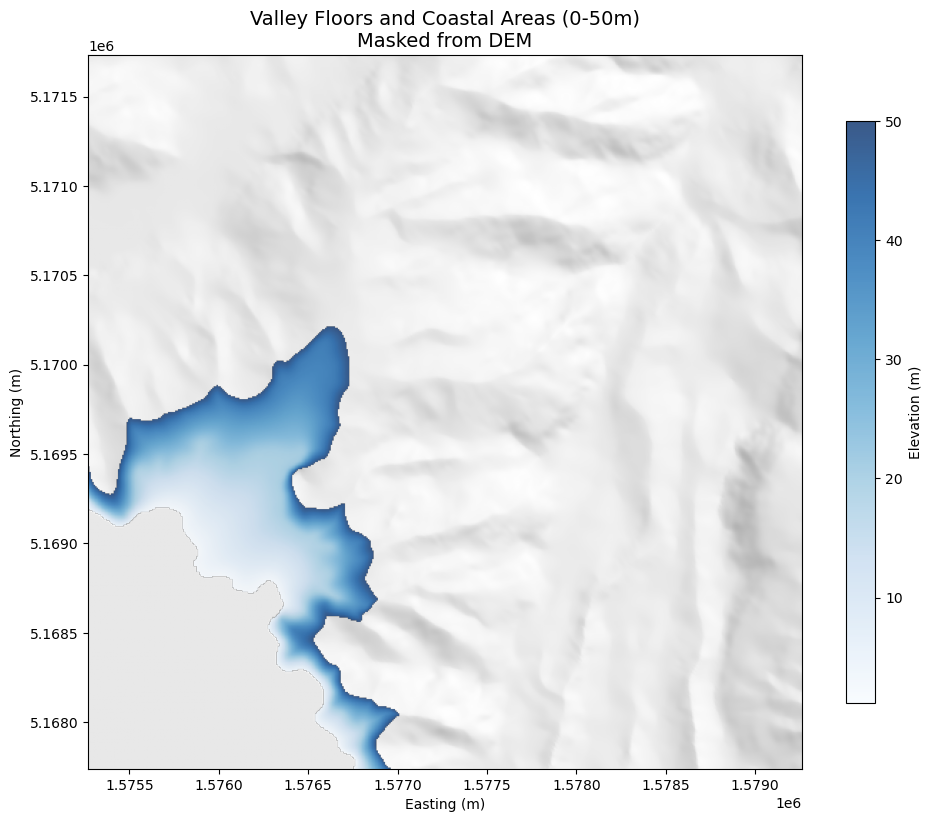

Low-elevation area (0-50m): 1.54 km²
Percentage of study area: 10.6%


In [8]:
# ── Masking: isolate the low-elevation valley floors ──
flood_mask = (dem > 0) & (dem <= 50)

# Apply mask (set other areas to NaN)
valley_dem = np.where(flood_mask, dem, np.nan)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hs, extent=extent, origin='lower', cmap='gray', alpha=0.3)
im = ax.imshow(valley_dem, extent=extent, origin='lower', cmap='Blues', alpha=0.8)
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.6)
ax.set_title('Valley Floors and Coastal Areas (0-50m)\nMasked from DEM', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

valley_area_km2 = np.sum(flood_mask) * cell_area / 1e6
print(f'Low-elevation area (0-50m): {valley_area_km2:.2f} km²')
print(f'Percentage of study area: {np.sum(flood_mask)/np.sum(dem>0)*100:.1f}%')

### 🔧 YOUR TURN: Map Algebra

1. Create a mask of areas with elevation between **200m and 400m** (mid-slope zone).
2. Calculate the area in km².
3. Plot the result on a hillshade background.

In [ ]:
# 🔧 YOUR TURN — mid-slope zone (200–400 m). Fill in the ... blanks.
# Every command here appeared in the flood-mask example above.

# TODO 1: Boolean mask for cells between 200 m and 400 m.
#   Pattern: (dem >= ...) & (dem <= ...)
mid_mask = ...

# TODO 2: Apply the mask — keep elevation inside the band, NaN everywhere else.
#   Command: np.where(mask, dem, np.nan)
mid_zone = ...

# TODO 3: Area of the band in km².
#   Pattern: np.sum(mask) * cell_area / 1e6
mid_area_km2 = ...
print(f'Mid-slope zone (200-400m) area: {mid_area_km2:.2f} km²')

# TODO 4: Plot it — hillshade underneath, the masked band on top.
#   Two ax.imshow() calls, both with extent=extent, origin='lower':
#   first hs with cmap='gray' and a low alpha, then mid_zone with a
#   colour map of your choice (e.g. 'YlOrBr').
fig, ax = plt.subplots(figsize=(10, 10))
...
ax.set_title('Mid-Slope Zone (200-400m)', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()


## 5. Terrain Derivatives: Slope and Aspect

### Slope
The **rate of change** of elevation — how steep the terrain is.
Critical for:
- Slope stability (landslide risk)
- Road gradient design
- Drainage direction
- Erosion potential

### Aspect
The **compass direction** a slope faces (0°=N, 90°=E, 180°=S, 270°=W).
Important for:
- Solar exposure (south-facing slopes receive less sun in NZ)
- Wind exposure
- Snow melt patterns

Both are **focal** operations — each cell's value depends on its 8 neighbours.

In [22]:
# ── Compute slope and aspect ──
dy, dx = np.gradient(dem, resolution)

# Slope in degrees
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

# Aspect in degrees (0-360, North = 0)
aspect_rad = np.arctan2(-dx, dy)
aspect_deg = np.degrees(aspect_rad)
aspect_deg = np.where(aspect_deg < 0, aspect_deg + 360, aspect_deg)

# Mask no-data areas
slope_display = np.where(dem > 0, slope_deg, np.nan)
aspect_display = np.where(dem > 0, aspect_deg, np.nan)

print(f'Slope range: {slope_deg[dem>0].min():.1f} to {slope_deg[dem>0].max():.1f} degrees')
print(f'Mean slope:  {slope_deg[dem>0].mean():.1f} degrees')
print(f'Aspect range: {aspect_deg[dem>0].min():.1f} to {aspect_deg[dem>0].max():.1f} degrees')

Slope range: 0.0 to 52.9 degrees
Mean slope:  17.0 degrees
Aspect range: 0.0 to 360.0 degrees


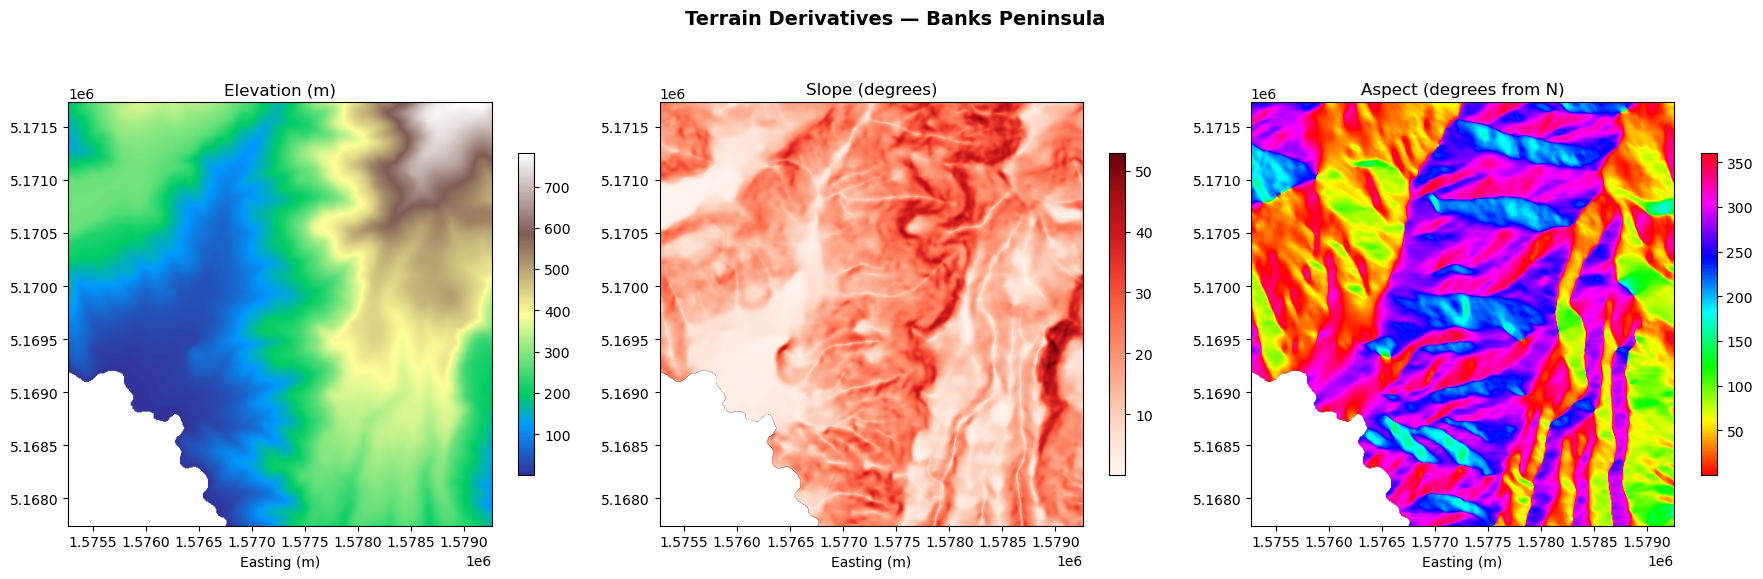

In [23]:
# Visualise slope and aspect
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# DEM
im1 = axes[0].imshow(dem_display, extent=extent, origin='lower', cmap='terrain')
axes[0].set_title('Elevation (m)', fontsize=12)
plt.colorbar(im1, ax=axes[0], shrink=0.6)

# Slope
im2 = axes[1].imshow(slope_display, extent=extent, origin='lower', cmap='Reds')
axes[1].set_title('Slope (degrees)', fontsize=12)
plt.colorbar(im2, ax=axes[1], shrink=0.6)

# Aspect
im3 = axes[2].imshow(aspect_display, extent=extent, origin='lower', cmap='hsv')
axes[2].set_title('Aspect (degrees from N)', fontsize=12)
plt.colorbar(im3, ax=axes[2], shrink=0.6)

for ax in axes:
    ax.set_xlabel('Easting (m)')

plt.suptitle('Terrain Derivatives — Banks Peninsula', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

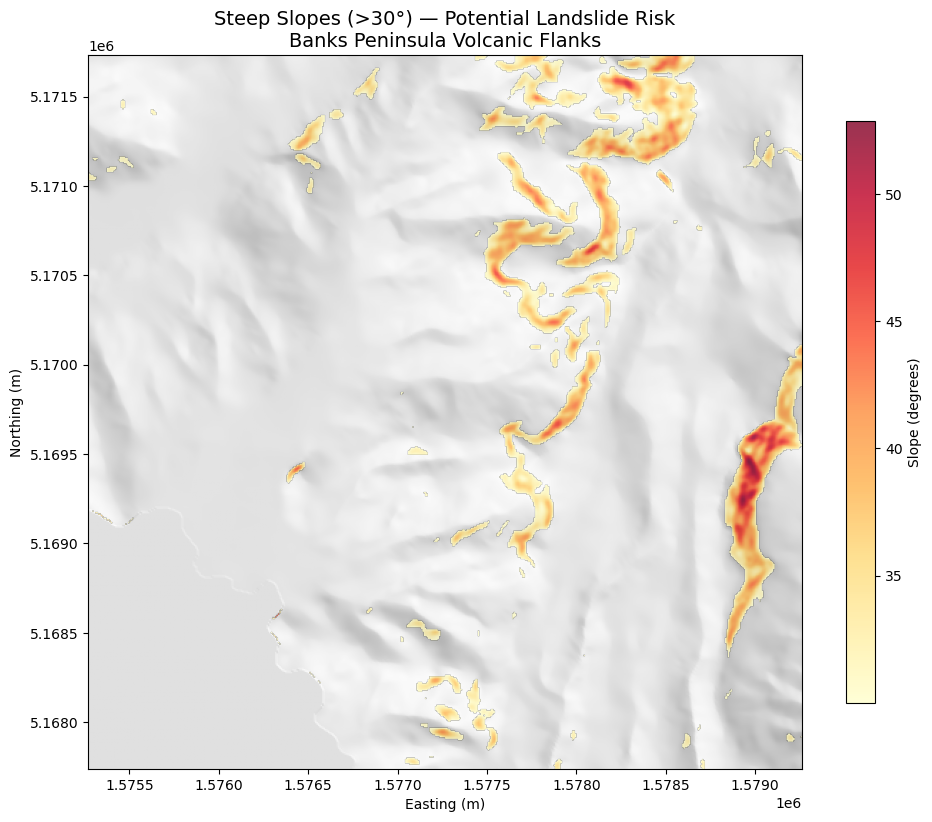

Steep slope area (>30°): 1.21 km²
Percentage of land area: 8.3%


In [24]:
# ── Engineering application: identify steep slopes (>30 degrees) ──
steep_threshold = 30
steep_mask = (slope_deg > steep_threshold) & (dem > 0)
steep_slopes = np.where(steep_mask, slope_deg, np.nan)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hs, extent=extent, origin='lower', cmap='gray', alpha=0.4)
im = ax.imshow(steep_slopes, extent=extent, origin='lower', cmap='YlOrRd', alpha=0.8)
plt.colorbar(im, ax=ax, label='Slope (degrees)', shrink=0.6)
ax.set_title(f'Steep Slopes (>{steep_threshold}°) — Potential Landslide Risk\n'
             'Banks Peninsula Volcanic Flanks', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

steep_area_km2 = np.sum(steep_mask) * cell_area / 1e6
print(f'Steep slope area (>{steep_threshold}°): {steep_area_km2:.2f} km²')
print(f'Percentage of land area: {np.sum(steep_mask)/np.sum(dem>0)*100:.1f}%')

## 6. Cropping Rasters with Vector Boundaries

In practice, you often need to **crop a raster to a study area boundary**.
We'll crop the DEM to focus on one of the volcanic peaks.

This simulates a real workflow: you download a regional DEM from LINZ
but only need a specific area for your engineering assessment.

Original DEM shape: (500, 500)
Cropped DEM shape:  (250, 250)
Cropped elevation range: 7.8m to 517.0m


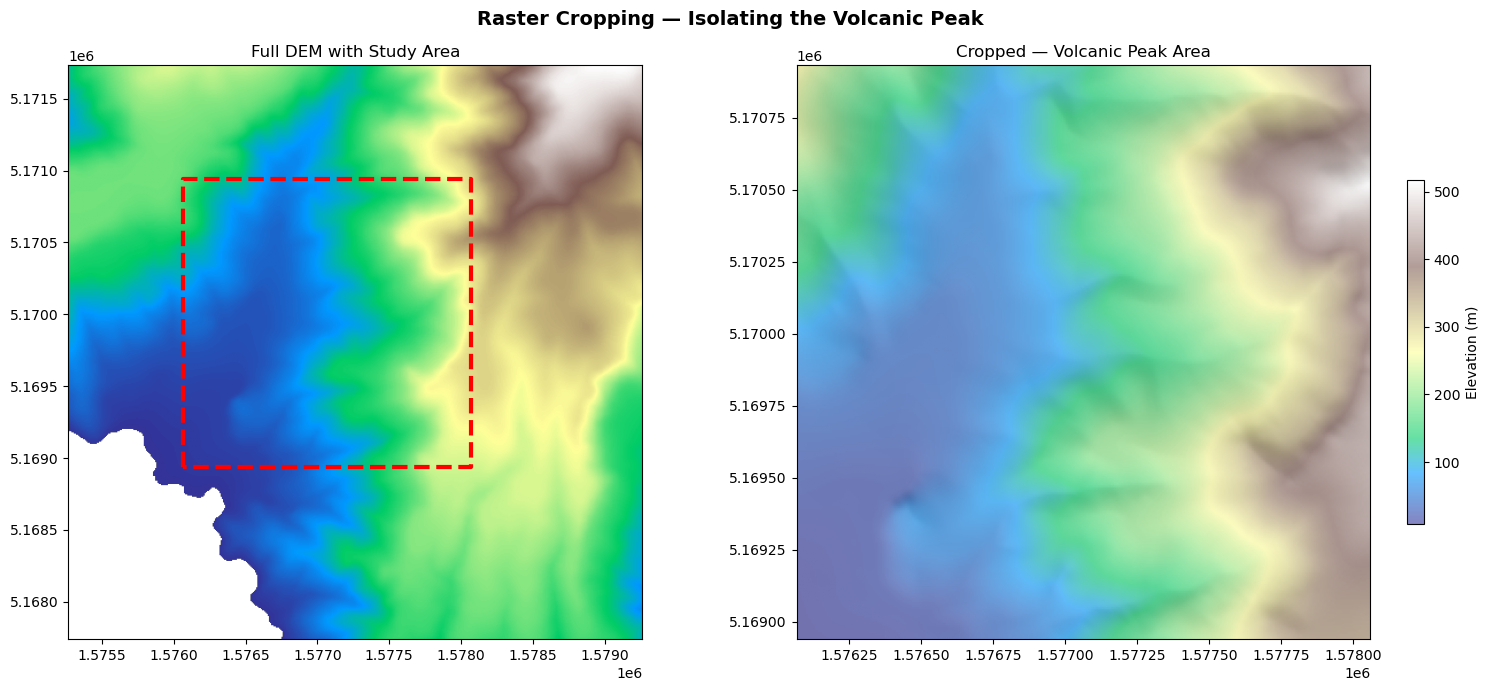

In [26]:
# Define a study area polygon (focus on the main volcanic peak)
peak_x0 = x_origin + 100 * resolution
peak_y0 = y_origin + 150 * resolution
peak_x1 = x_origin + 350 * resolution
peak_y1 = y_origin + 400 * resolution

study_poly = box(peak_x0, peak_y0, peak_x1, peak_y1)
study_gdf = gpd.GeoDataFrame({'name': ['Volcanic Peak Study Area']},
                              geometry=[study_poly], crs='EPSG:2193')

# Compute array indices from coordinates
col_min = max(0, int((peak_x0 - x_origin) / resolution))
col_max = min(ncols, int((peak_x1 - x_origin) / resolution))
row_min = max(0, int((peak_y0 - y_origin) / resolution))
row_max = min(nrows, int((peak_y1 - y_origin) / resolution))

# Crop the arrays
dem_crop = dem[row_min:row_max, col_min:col_max]
slope_crop = slope_deg[row_min:row_max, col_min:col_max]
hs_crop = compute_hillshade(dem_crop, resolution=resolution)
x_crop = x_coords[col_min:col_max]
y_crop = y_coords[row_min:row_max]
extent_crop = [x_crop[0], x_crop[-1], y_crop[0], y_crop[-1]]

print(f'Original DEM shape: {dem.shape}')
print(f'Cropped DEM shape:  {dem_crop.shape}')
print(f'Cropped elevation range: {dem_crop[dem_crop>0].min():.1f}m to {dem_crop.max():.1f}m')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full DEM with study area outline
im1 = axes[0].imshow(dem_display, extent=extent, origin='lower', cmap='terrain')
study_gdf.boundary.plot(ax=axes[0], color='red', linewidth=3, linestyle='--')
axes[0].set_title('Full DEM with Study Area', fontsize=12)

# Cropped DEM with hillshade
dem_crop_display = np.where(dem_crop > 0, dem_crop, np.nan)
axes[1].imshow(hs_crop, extent=extent_crop, origin='lower', cmap='gray', alpha=0.5)
im2 = axes[1].imshow(dem_crop_display, extent=extent_crop, origin='lower',
                      cmap='terrain', alpha=0.6)
axes[1].set_title('Cropped — Volcanic Peak Area', fontsize=12)
plt.colorbar(im2, ax=axes[1], shrink=0.6, label='Elevation (m)')

plt.suptitle('Raster Cropping — Isolating the Volcanic Peak',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Extracting Raster Values at Point Locations

A common engineering task: **What is the elevation/slope/hazard intensity at each building?**

This is the raster equivalent of a spatial join — linking a continuous surface
to discrete point features. We'll place buildings across Banks Peninsula
and extract the elevation and slope at each location.

In [27]:
# Generate building locations within the DEM extent
np.random.seed(123)
n_bldg = 80

# Only place buildings where there is valid elevation data
valid_rows, valid_cols = np.where(dem > 0)
sample_idx = np.random.choice(len(valid_rows), n_bldg, replace=False)
bldg_rows = valid_rows[sample_idx]
bldg_cols = valid_cols[sample_idx]
bldg_x = x_origin + bldg_cols * resolution + resolution / 2
bldg_y = y_origin + bldg_rows * resolution + resolution / 2

buildings = gpd.GeoDataFrame({
    'bldg_id': [f'BLD-{i:03d}' for i in range(n_bldg)],
    'type': np.random.choice(['Residential', 'Commercial', 'School'], n_bldg, p=[0.7, 0.2, 0.1]),
    'geometry': [Point(x, y) for x, y in zip(bldg_x, bldg_y)]
}, crs='EPSG:2193')

# Extract DEM elevation at each building location
def extract_raster_value(point, raster, x_origin, y_origin, resolution):
    """Extract raster value at a point location."""
    col = int((point.x - x_origin) / resolution)
    row = int((point.y - y_origin) / resolution)
    if 0 <= row < raster.shape[0] and 0 <= col < raster.shape[1]:
        return float(raster[row, col])
    return np.nan

buildings['elevation_m'] = buildings.geometry.apply(
    lambda p: extract_raster_value(p, dem, x_origin, y_origin, resolution)
)
buildings['slope_deg'] = buildings.geometry.apply(
    lambda p: extract_raster_value(p, slope_deg, x_origin, y_origin, resolution)
)

print('Buildings with extracted raster values:')
print(buildings[['bldg_id', 'type', 'elevation_m', 'slope_deg']].head(10).to_string(index=False))

Buildings with extracted raster values:
bldg_id        type  elevation_m  slope_deg
BLD-000  Commercial    41.956089   9.554646
BLD-001 Residential     2.406053   1.964151
BLD-002 Residential   208.996109   8.984280
BLD-003      School   676.761292  19.575680
BLD-004 Residential   429.336334  31.779663
BLD-005  Commercial   141.769119  16.862503
BLD-006  Commercial   455.124908  39.424679
BLD-007 Residential   299.757263   4.181367
BLD-008 Residential   289.688690  16.498611
BLD-009  Commercial   490.931549  27.220022


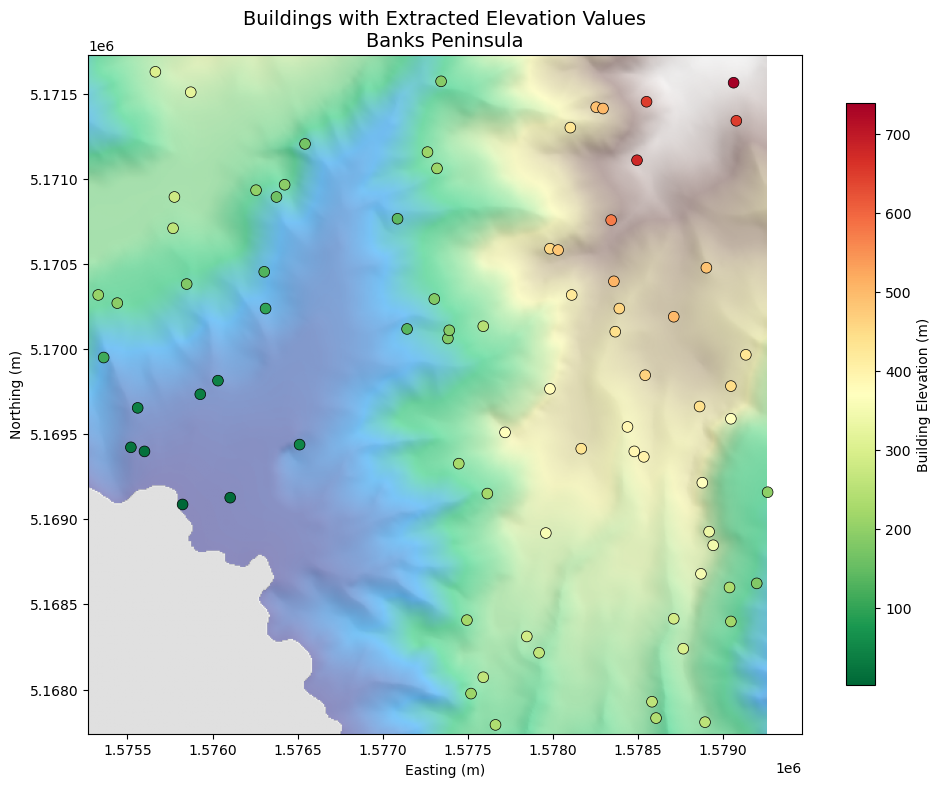


Elevation statistics at building locations:
  Min: 2.4m
  Max: 739.0m
  Mean: 294.8m

Buildings on steep slopes (>25°): 20


In [28]:
# Plot buildings on DEM coloured by extracted elevation
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hs, extent=extent, origin='lower', cmap='gray', alpha=0.4)
im = ax.imshow(dem_display, extent=extent, origin='lower', cmap='terrain', alpha=0.5)

sc = ax.scatter(bldg_x, bldg_y, c=buildings['elevation_m'], cmap='RdYlGn_r',
                s=60, edgecolor='black', linewidth=0.5, zorder=5)
plt.colorbar(sc, ax=ax, label='Building Elevation (m)', shrink=0.6)
ax.set_title('Buildings with Extracted Elevation Values\nBanks Peninsula', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

# Summary statistics
print(f'\nElevation statistics at building locations:')
print(f'  Min: {buildings["elevation_m"].min():.1f}m')
print(f'  Max: {buildings["elevation_m"].max():.1f}m')
print(f'  Mean: {buildings["elevation_m"].mean():.1f}m')
print(f'\nBuildings on steep slopes (>25°): {(buildings["slope_deg"] > 25).sum()}')

## 8. Combining Raster and Vector: Seismic Hazard Assessment

### Scenario
You have a raster representing **Peak Ground Acceleration (PGA)** from a simulated
earthquake scenario on one of the faults near Banks Peninsula. You need to extract
the PGA at each building location to determine structural demand.

PGA values:
- < 0.1g: Light shaking (minor damage)
- 0.1–0.3g: Moderate shaking (moderate damage)
- 0.3–0.5g: Strong shaking (significant damage)
- \> 0.5g: Very strong shaking (severe damage)

**Note:** The PGA raster here is synthetic (simplified attenuation from a point source),
but the workflow is identical to what you would do with real GNS Science hazard maps.

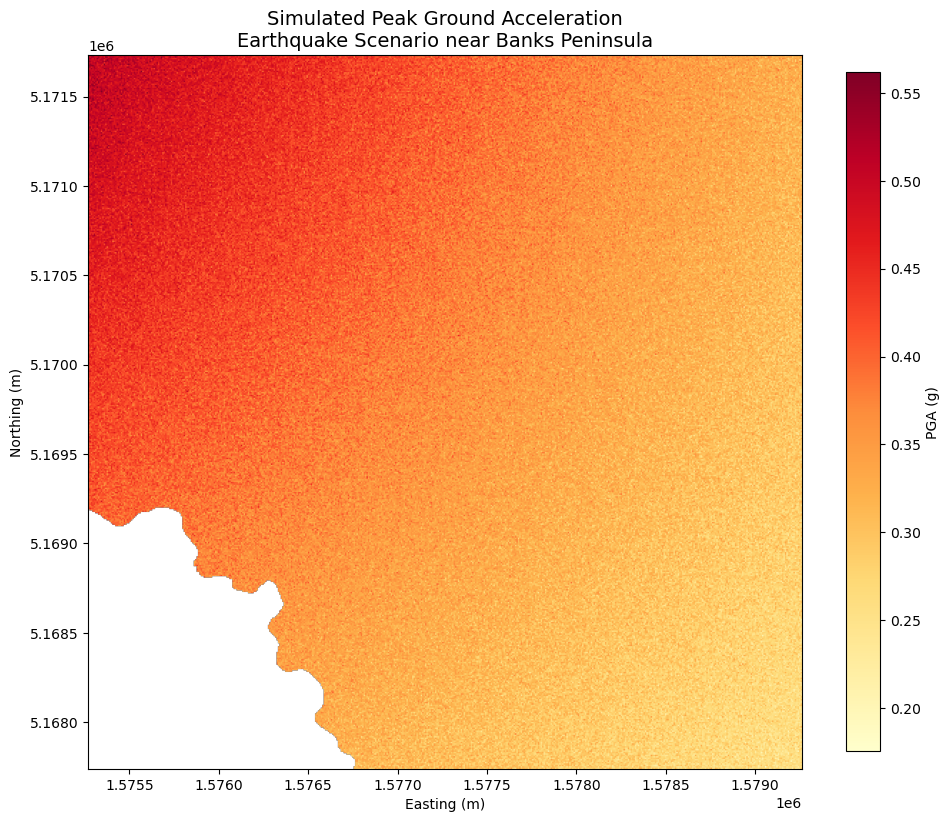

In [16]:
# Create a synthetic PGA raster (seismic hazard)
# Earthquake source to the northwest — PGA decreases with distance
source_x = x_origin - 3000
source_y = y_origin + nrows * resolution + 2000

dist_from_source = np.sqrt((X - source_x)**2 + (Y - source_y)**2)
pga = 0.8 * np.exp(-dist_from_source / 8000) + np.random.normal(0, 0.02, dem.shape)
pga = np.clip(pga, 0.01, 1.0)
pga_display = np.where(dem > 0, pga, np.nan)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(pga_display, extent=extent, origin='lower', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='PGA (g)', shrink=0.7)
ax.set_title('Simulated Peak Ground Acceleration\nEarthquake Scenario near Banks Peninsula',
             fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

In [29]:
# Extract PGA at building locations
buildings['pga_g'] = buildings.geometry.apply(
    lambda p: extract_raster_value(p, pga, x_origin, y_origin, resolution)
)

# Classify damage potential
def damage_class(pga_val):
    if pga_val < 0.1: return 'Light'
    elif pga_val < 0.3: return 'Moderate'
    elif pga_val < 0.5: return 'Strong'
    else: return 'Severe'

buildings['damage_potential'] = buildings['pga_g'].apply(damage_class)

print('Seismic Hazard at Building Locations:')
print(buildings[['bldg_id', 'type', 'elevation_m', 'pga_g', 'damage_potential']].head(10).to_string(index=False))
print(f'\nDamage Potential Summary:')
print(buildings['damage_potential'].value_counts().to_string())

Seismic Hazard at Building Locations:
bldg_id        type  elevation_m    pga_g damage_potential
BLD-000  Commercial    41.956089 0.405351           Strong
BLD-001 Residential     2.406053 0.354088           Strong
BLD-002 Residential   208.996109 0.489053           Strong
BLD-003      School   676.761292 0.355460           Strong
BLD-004 Residential   429.336334 0.356989           Strong
BLD-005  Commercial   141.769119 0.400987           Strong
BLD-006  Commercial   455.124908 0.379451           Strong
BLD-007 Residential   299.757263 0.265599         Moderate
BLD-008 Residential   289.688690 0.280774         Moderate
BLD-009  Commercial   490.931549 0.343922           Strong

Damage Potential Summary:
damage_potential
Strong      60
Moderate    19
Severe       1


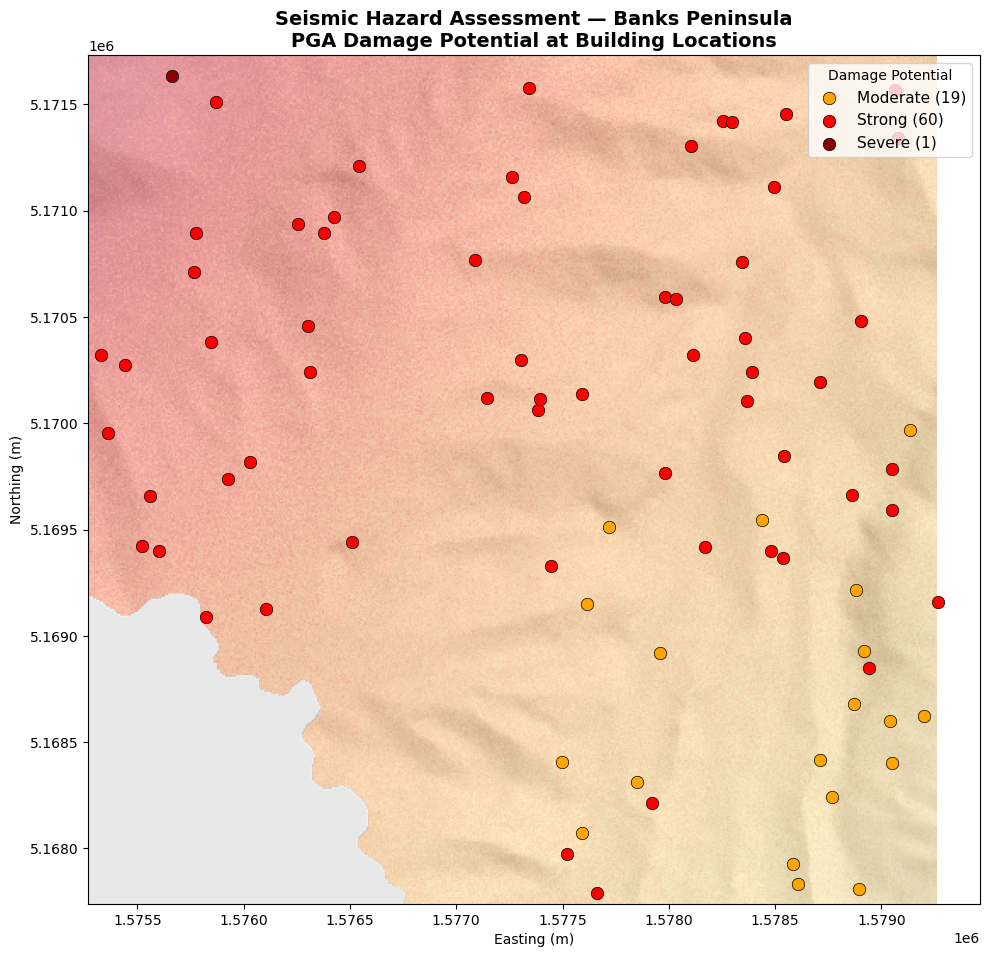

In [30]:
# Final map: buildings coloured by damage potential on PGA raster
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hs, extent=extent, origin='lower', cmap='gray', alpha=0.3)
ax.imshow(pga_display, extent=extent, origin='lower', cmap='YlOrRd', alpha=0.4)

color_map = {'Light': 'green', 'Moderate': 'orange', 'Strong': 'red', 'Severe': 'darkred'}
for cls, color in color_map.items():
    subset = buildings[buildings['damage_potential'] == cls]
    if len(subset) > 0:
        ax.scatter(subset.geometry.x, subset.geometry.y,
                  c=color, s=80, edgecolor='black', linewidth=0.5,
                  label=f'{cls} ({len(subset)})', zorder=5)

ax.set_title('Seismic Hazard Assessment — Banks Peninsula\n'
             'PGA Damage Potential at Building Locations',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, title='Damage Potential')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

## 9. Zonal Statistics

**Zonal statistics** summarise raster values within vector zones.
For example: "What is the average elevation in each quadrant of the study area?"

This combines the strengths of both data models:
- **Raster**: continuous surface information
- **Vector**: meaningful spatial boundaries for aggregation

We'll divide Banks Peninsula into four quadrants representing different
landscape settings.

In [33]:
# Create zone polygons — quadrants of the study area
x_mid = x_origin + ncols * resolution / 2
y_mid = y_origin + nrows * resolution / 2
x_max = x_origin + ncols * resolution
y_max = y_origin + nrows * resolution

zones = [
    {'zone': 'NW — Harbour', 'geometry': box(x_origin, y_mid, x_mid, y_max)},
    {'zone': 'NE — Peak', 'geometry': box(x_mid, y_mid, x_max, y_max)},
    {'zone': 'SW — Coastal', 'geometry': box(x_origin, y_origin, x_mid, y_mid)},
    {'zone': 'SE — Valleys', 'geometry': box(x_mid, y_origin, x_max, y_mid)},
]
zone_gdf = gpd.GeoDataFrame(zones, crs='EPSG:2193')

# Compute zonal statistics using array slicing
half_r = nrows // 2
half_c = ncols // 2

slices = {
    'NW — Harbour': (slice(half_r, nrows), slice(0, half_c)),
    'NE — Peak': (slice(half_r, nrows), slice(half_c, ncols)),
    'SW — Coastal':    (slice(0, half_r), slice(0, half_c)),
    'SE — Valleys': (slice(0, half_r), slice(half_c, ncols)),
}

print('Zonal Statistics Summary:')
print(f'{"Zone":<16} {"Mean Elev":>10} {"Max Elev":>10} {"Mean Slope":>11} {"Mean PGA":>10}')
print('-' * 62)

for name, (rs, cs) in slices.items():
    z_dem = dem[rs, cs]
    z_slope = slope_deg[rs, cs]
    z_pga = pga[rs, cs]
    valid = z_dem > 0
    if valid.sum() > 0:
        print(f'{name:<16} {z_dem[valid].mean():>9.1f}m {z_dem[valid].max():>9.1f}m '
              f'{z_slope[valid].mean():>10.1f}° {z_pga[valid].mean():>9.3f}g')
    else:
        print(f'{name:<16} {"No data":>10}')

Zonal Statistics Summary:
Zone              Mean Elev   Max Elev  Mean Slope   Mean PGA
--------------------------------------------------------------
NW — Harbour         175.4m     361.3m       14.4°     0.428g
NE — Peak            450.5m     780.5m       21.9°     0.346g
SW — Coastal          60.9m     211.7m       12.7°     0.361g
SE — Valleys         294.0m     467.3m       17.2°     0.302g


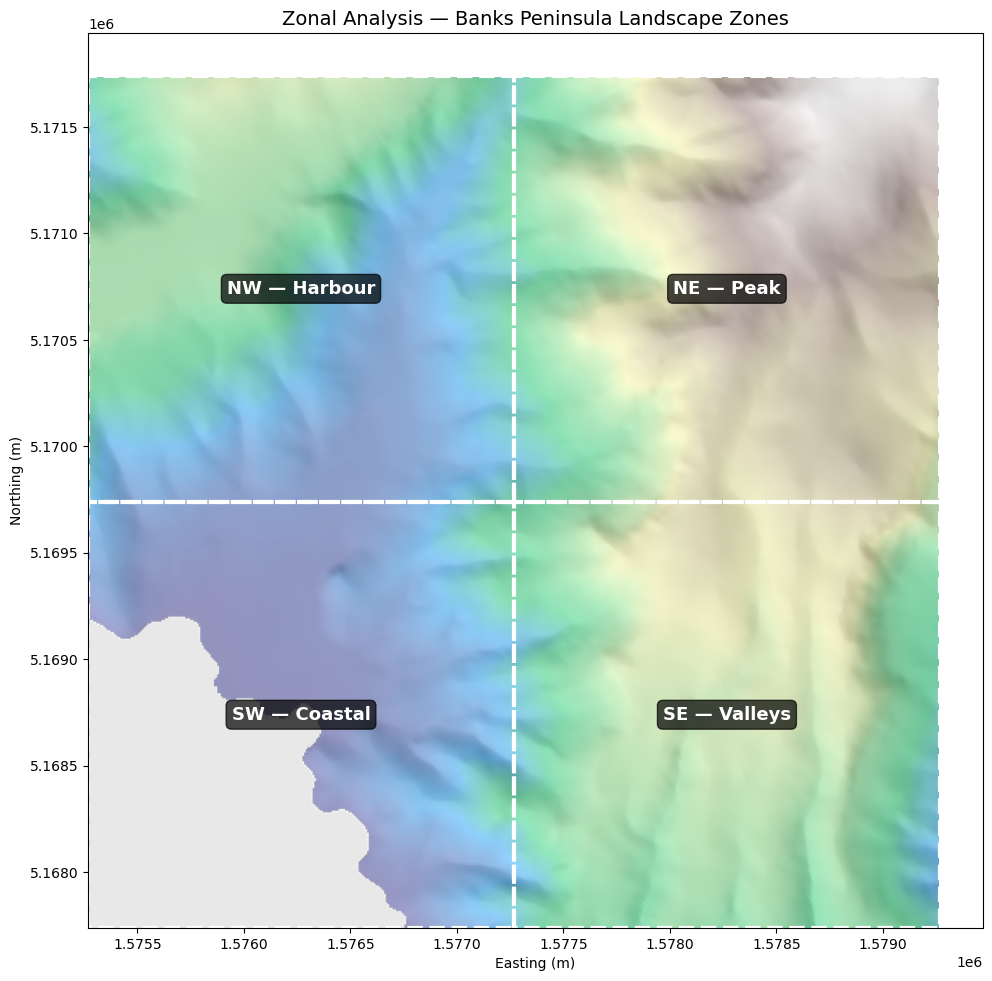

In [34]:
# Visualise zones on DEM
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(dem_display, extent=extent, origin='lower', cmap='terrain', alpha=0.6)
ax.imshow(hs, extent=extent, origin='lower', cmap='gray', alpha=0.3)
zone_gdf.boundary.plot(ax=ax, color='white', linewidth=3, linestyle='--')

for idx, row in zone_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['zone'], fontsize=13, fontweight='bold',
            color='white', ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

ax.set_title('Zonal Analysis — Banks Peninsula Landscape Zones', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

## 10. Elevation Distribution (Hypsometric Curve)

A **hypsometric curve** shows the cumulative distribution of area with elevation.
This is a **global** raster operation — it uses the entire grid to compute
a single summary. It reveals the overall terrain character of a landscape.

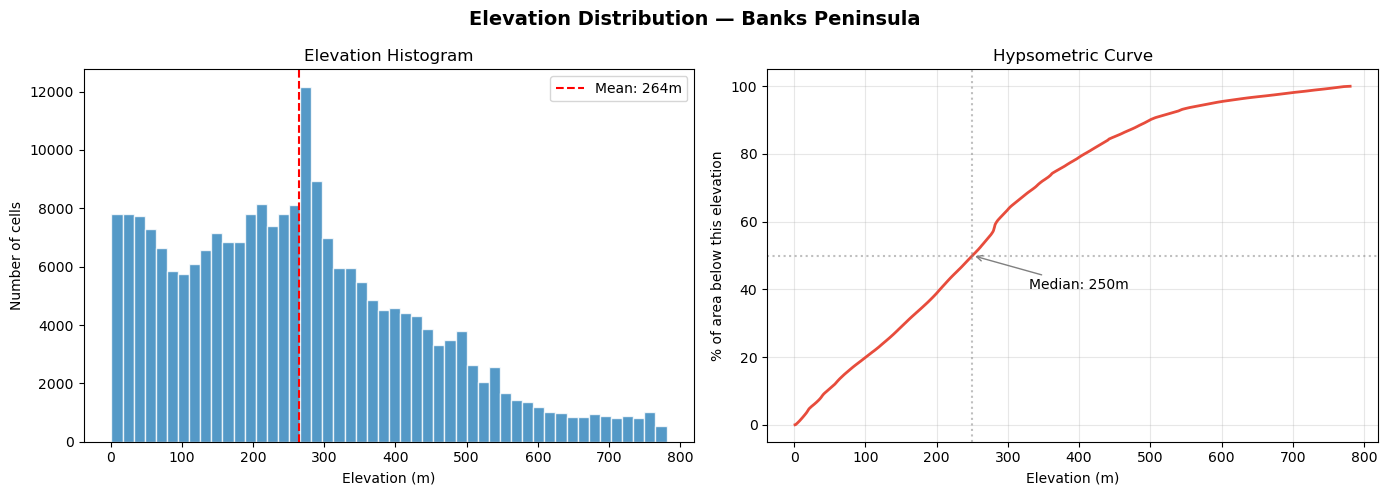

Total land cells: 226,827
Total land area: 14.52 km²
Median elevation: 250m
Mean elevation: 264m


In [35]:
valid_elev = dem[dem > 0].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(valid_elev, bins=50, color='#2980b9', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Elevation (m)')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Elevation Histogram', fontsize=12)
axes[0].axvline(valid_elev.mean(), color='red', linestyle='--', label=f'Mean: {valid_elev.mean():.0f}m')
axes[0].legend()

# Hypsometric curve (cumulative)
sorted_elev = np.sort(valid_elev)
cumulative = np.arange(1, len(sorted_elev) + 1) / len(sorted_elev) * 100
axes[1].plot(sorted_elev, cumulative, color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Elevation (m)')
axes[1].set_ylabel('% of area below this elevation')
axes[1].set_title('Hypsometric Curve', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(50, color='gray', linestyle=':', alpha=0.5)
median_elev = np.median(valid_elev)
axes[1].axvline(median_elev, color='gray', linestyle=':', alpha=0.5)
axes[1].annotate(f'Median: {median_elev:.0f}m', xy=(median_elev, 50),
                 xytext=(median_elev + 80, 40), fontsize=10,
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle('Elevation Distribution — Banks Peninsula',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total land cells: {len(valid_elev):,}')
print(f'Total land area: {len(valid_elev) * cell_area / 1e6:.2f} km²')
print(f'Median elevation: {median_elev:.0f}m')
print(f'Mean elevation: {valid_elev.mean():.0f}m')

## 11. Summary and Reflection

### What You Learned Today
1. **DEM structure**: Rasters are grids of cells; each cell holds a numeric value
2. **Hillshade**: Simulates terrain illumination — a focal operation
3. **Map algebra**: Reclassification, masking, and arithmetic — local operations
4. **Terrain derivatives**: Slope and aspect computed from elevation gradients — focal operations
5. **Raster cropping**: Extract data within a study area boundary
6. **Point extraction**: Extract raster values at discrete locations
7. **Zonal statistics**: Summarise raster values within vector zones
8. **Hazard assessment**: Combine PGA raster with building locations
9. **Hypsometric analysis**: Global operations summarising the whole raster

### Engineering Takeaways
- **Real terrain is complex**: Banks Peninsula's volcanic landscape produces much steeper
  slopes and more varied aspect patterns than the Canterbury Plains
- **Slope analysis** directly informs stability, drainage, and design decisions
- **Extracting raster values at points** links continuous surfaces to discrete assets
- **Zonal statistics** enable area-based reporting for engineering assessments
- **Sun direction matters**: different hillshade azimuths reveal different terrain features

### Reflection Questions
1. How does the 8m resolution of this DEM affect the accuracy of slope calculations
   compared to, say, a 1m LiDAR DEM?
2. Why is it important to use a projected CRS (NZTM2000) when computing slope from a DEM?
3. Looking at the hypsometric curve, what does the shape tell you about Banks Peninsula's
   terrain compared to a flat alluvial plain?

---

### Assessment: Lab Sign-Off

**This lab is not complete until you have submitted your sign-off to LEARN.**

**Step 1 — Self-check.** Make sure you can do each of these:

- [ ] Loaded and inspected the real Banks Peninsula DEM
- [ ] Created hillshade visualisations with different sun angles
- [ ] Performed map algebra (reclassification and masking)
- [ ] Computed slope and identified steep areas on the volcanic flanks
- [ ] Extracted raster values at building locations
- [ ] Completed the seismic hazard assessment map
- [ ] Computed zonal statistics and interpreted the results

**Step 2 — Take the sign-off quiz.**

1. Download **`Lab3_SignOff.html`** from LEARN and open it in your web browser.
2. Enter your full name and University ID, then answer the 10 questions.
3. You need **8/10** to pass. You can retake it as often as you like — each
   attempt draws a new set of questions, and every answer comes with an explanation.
4. When you pass, click **Download Sign-Off PNG**. This saves a file called
   `ENCN205_Lab3_<yourID>.png` to your computer.

**Step 3 — Submit.** Upload `ENCN205_Lab3_<yourID>.png` to the **Lab 3 Sign-Off**
submission on LEARN.

> Your PNG records your name, ID, score, and a timestamp, encoded in the QR code.
> It is your proof of completion — show it to your tutor if they ask.
